<a href="https://colab.research.google.com/github/ibrahimsaqib-ai/Introduction-to-AI-Labs/blob/main/Lab-05/diabetes_data_exploration_and_logistic_regressi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os

def auto_find_dataset(filename):
    for root, dirs, files in os.walk('/content'):
        if filename.lower() in [f.lower() for f in files]:
            return os.path.join(root, filename)
    return None

data_path = auto_find_dataset('diabetes.csv')

if data_path:
    print(f"File found: {data_path}")
    df = pd.read_csv(data_path, encoding='ascii', delimiter=',')
    display(df.head())
else:
    print("File not found! Please upload 'diabetes.csv' to the files panel.")

File found: /content/sample_data/diabetes.csv


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72.0,35,169.5,33.6,0.627,50,1
1,85,66.0,29,102.5,26.6,0.351,31,0
2,183,64.0,32,169.5,23.3,0.672,32,1
3,89,66.0,23,94.0,28.1,0.167,21,0
4,137,40.0,35,168.0,43.1,2.288,33,1


### Load Dataset

In [ ]:
# Cleaned up

In [ ]:
from sklearn.model_selection import train_test_split
# Prepare features and target variable
X = df[['Age', 'BMI', 'BloodPressure', 'Insulin', 'Glucose', 'DiabetesPedigreeFunction']]
y = df['Outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

### Environment Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_test

,Age,BMI,BloodPressure,Insulin,Glucose,DiabetesPedigreeFunction
668,43,34.0,58.0,190.0,98,0.430
324,21,35.7,75.0,102.5,112,0.148
624,21,30.8,64.0,102.5,108,0.158
690,34,24.6,80.0,102.5,107,0.856
473,50,29.9,90.0,102.5,136,0.210
...,...,...,...,...,...,...
355,49,30.4,88.0,169.5,165,0.302
534,24,33.3,56.0,56.0,77,1.251
344,57,36.8,72.0,102.5,95,0.485
296,29,28.0,70.0,360.0,146,0.337


In [ ]:
# Weights
print(model.coef_)

# Constant / intercept
print(model.intercept_)

[[ 0.04559683  0.09394991 -0.00964773  0.00442035  0.03010364  0.48521205]]
[-9.2358725]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

Accuracy Score: 0.7597


In [ ]:
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

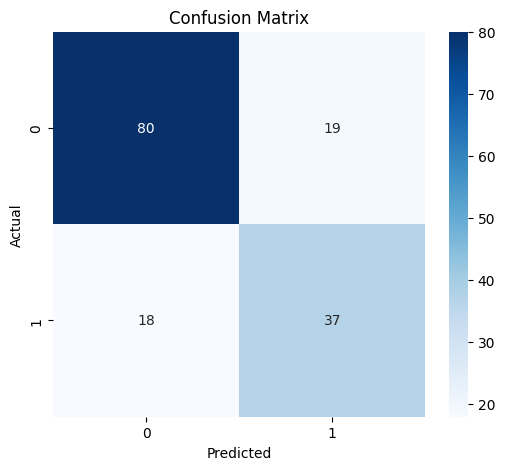

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Generate the confusion matrix and visualize using heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
21,35.7,75.0,102.5,112,0.148

(21, 35.7, 75.0, 102.5, 112, 0.148)

In [ ]:
# Dataset se 'Age' column ko drop karne ke liye
X_new = X.drop(columns=['Age'])

# Updated features ko display karke check karte hain
display(X_new.head())

,BMI,BloodPressure,Insulin,Glucose,DiabetesPedigreeFunction
0,33.6,72.0,169.5,148,0.627
1,26.6,66.0,102.5,85,0.351
2,23.3,64.0,169.5,183,0.672
3,28.1,66.0,94.0,89,0.167
4,43.1,40.0,168.0,137,2.288


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split training and testing sets without 'Age'
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Train new model
model_new = LogisticRegression(max_iter=1000)
model_new.fit(X_train_new, y_train_new)

# Evaluate accuracy
y_pred_new = model_new.predict(X_test_new)
accuracy_new = accuracy_score(y_test_new, y_pred_new)
print(f'New Accuracy Score (without Age): {accuracy_new:.4f}')

New Accuracy Score (without Age): 0.7987


Features correlation with Outcome:
DiabetesPedigreeFunction    0.173844
BloodPressure               0.174469
Age                         0.238356
SkinThickness               0.295138
BMI                         0.315577
Insulin                     0.377081
Glucose                     0.495990
Outcome                     1.000000
Name: Outcome, dtype: float64


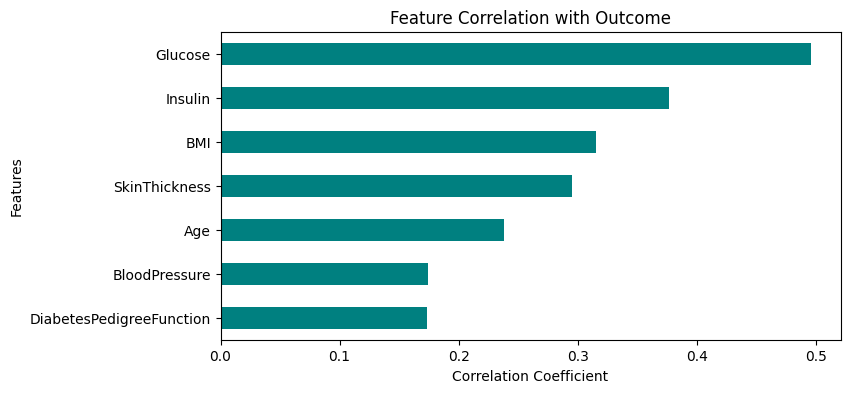

In [ ]:
# Har feature ka 'Outcome' ke sath correlation check karte hain
correlations = df.corr()['Outcome'].sort_values()
print("Features correlation with Outcome:")
print(correlations)

# Is correlation ko visual karne ke liye bar plot banate hain
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
correlations.drop('Outcome').plot(kind='barh', color='teal')
plt.title('Feature Correlation with Outcome')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

In [ ]:
# 'Age' aur 'BloodPressure' dono columns ko drop karte hain
X_no_bp = X.drop(columns=['Age', 'BloodPressure'])

# Split training and testing sets
X_train_bp, X_test_bp, y_train_bp, y_test_bp = train_test_split(X_no_bp, y, test_size=0.2, random_state=42)

# Train the model
model_no_bp = LogisticRegression(max_iter=1000)
model_no_bp.fit(X_train_bp, y_train_bp)

# Evaluate accuracy
y_pred_bp = model_no_bp.predict(X_test_bp)
accuracy_bp = accuracy_score(y_test_bp, y_pred_bp)

print(f'New Accuracy Score (without Age & BloodPressure): {accuracy_bp:.4f}')

New Accuracy Score (without Age & BloodPressure): 0.7922


In [ ]:
# 'Age', 'BloodPressure', aur 'DiabetesPedigreeFunction' teeno ko drop karte hain
X_three_dropped = X.drop(columns=['Age', 'BloodPressure', 'DiabetesPedigreeFunction'])

# Split training and testing sets
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_three_dropped, y, test_size=0.2, random_state=42)

# Train the model
model_3 = LogisticRegression(max_iter=1000)
model_3.fit(X_train_3, y_train_3)

# Evaluate accuracy
y_pred_3 = model_3.predict(X_test_3)
accuracy_3 = accuracy_score(y_test_3, y_pred_3)

print(f'New Accuracy Score (without Age, BloodPressure & DiabetesPedigreeFunction): {accuracy_3:.4f}')

New Accuracy Score (without Age, BloodPressure & DiabetesPedigreeFunction): 0.7792
